# Pandas Time Series

Analysis of U.S. light vehicle sales (FRED series `ALTSALES`) using
Pandas time series tools: `DatetimeIndex`, `pd.date_range`,
`.resample()`, `.shift()`, `.diff()`, and `.rolling()`.

**roadmap.sh project:**
https://roadmap.sh/projects/pandas-time-series

## Setup & Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (11, 5)

## Load data

Light Weight Vehicle Sales: Autos and Light Trucks (`ALTSALES`),
millions of units, seasonally adjusted annual rate — sourced
directly from the FRED CSV endpoint.

In [2]:
FRED_URL = (
    "https://fred.stlouisfed.org/graph/fredgraph.csv?id=ALTSALES"
)
raw = pd.read_csv(FRED_URL)
raw.head()

,observation_date,ALTSALES
0,1976-01-01,12.512
1,1976-02-01,13.044
2,1976-03-01,13.085
3,1976-04-01,12.915
4,1976-05-01,12.645


## Date processing

Parse `observation_date` and set it as a `DatetimeIndex` so the
DataFrame can be resampled, shifted, and rolled over time.

In [3]:
sales = raw.copy()
sales["observation_date"] = pd.to_datetime(
    sales["observation_date"]
)
sales = sales.set_index("observation_date")
sales = sales.rename(columns={"ALTSALES": "units_millions"})
sales.index.name = "date"

print(type(sales.index))
sales.info()

<class 'pandas.DatetimeIndex'>
<class 'pandas.DataFrame'>
DatetimeIndex: 606 entries, 1976-01-01 to 2026-06-01
Data columns (total 1 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   units_millions  606 non-null    float64
dtypes: float64(1)
memory usage: 9.5 KB


## Date range creation

`pd.date_range()` builds evenly spaced `DatetimeIndex` objects from
a frequency string — `D` (calendar day), `W` (week), `MS`
(month start), `QS` (quarter start). Reindexing the monthly sales
series onto its own month-start range confirms there are no gaps.

In [4]:
monthly_range = pd.date_range(
    start=sales.index.min(),
    end=sales.index.max(),
    freq="MS",
)
print(f"Range length: {len(monthly_range)}")
print(f"Sales rows:    {len(sales)}")
missing = monthly_range.difference(sales.index)
print(f"Missing months: {len(missing)}")

Range length: 606
Sales rows:    606
Missing months: 0


## Resampling

The raw series is already monthly. `.resample("MS").mean()`
confirms that (a no-op aggregation), while `.resample("QS").mean()`
rolls three months at a time into a quarterly average — the
aggregation step that matters when the frequency actually changes.

In [5]:
monthly = sales["units_millions"].resample("MS").mean()
quarterly = sales["units_millions"].resample("QS").mean()

print(f"Monthly rows:   {len(monthly)}")
print(f"Quarterly rows: {len(quarterly)}")
quarterly.tail()

Monthly rows:   606
Quarterly rows: 202


date
2025-04-01    16.183333
2025-07-01    16.559000
2025-10-01    15.727333
2026-01-01    15.470667
2026-04-01    16.269333
Freq: QS-JAN, Name: units_millions, dtype: float64

## Time shift & period-over-period change

`.shift(1)` moves the series forward one period so each row sits
next to its prior-month value. Subtracting (or using `.diff()`
directly) yields the month-over-month change; dividing by the
shifted value gives the percentage change — the standard way to
study momentum in a sales series.

In [6]:
monthly_df = monthly.to_frame()
monthly_df["prev_month"] = monthly_df["units_millions"].shift(1)
monthly_df["mom_change"] = monthly_df["units_millions"].diff()
monthly_df["mom_pct_change"] = monthly_df[
    "units_millions"
].pct_change() * 100
monthly_df.tail()

,units_millions,prev_month,mom_change,mom_pct_change
date,,,,
2026-02-01,15.505,14.598,0.907,6.213180
2026-03-01,16.309,15.505,0.804,5.185424
2026-04-01,16.205,16.309,-0.104,-0.637685
2026-05-01,16.080,16.205,-0.125,-0.771367
2026-06-01,16.523,16.080,0.443,2.754975


## Visualization

Original monthly series plotted against its 12-month rolling
mean — the rolling mean smooths seasonal swings and shows the
underlying trend.

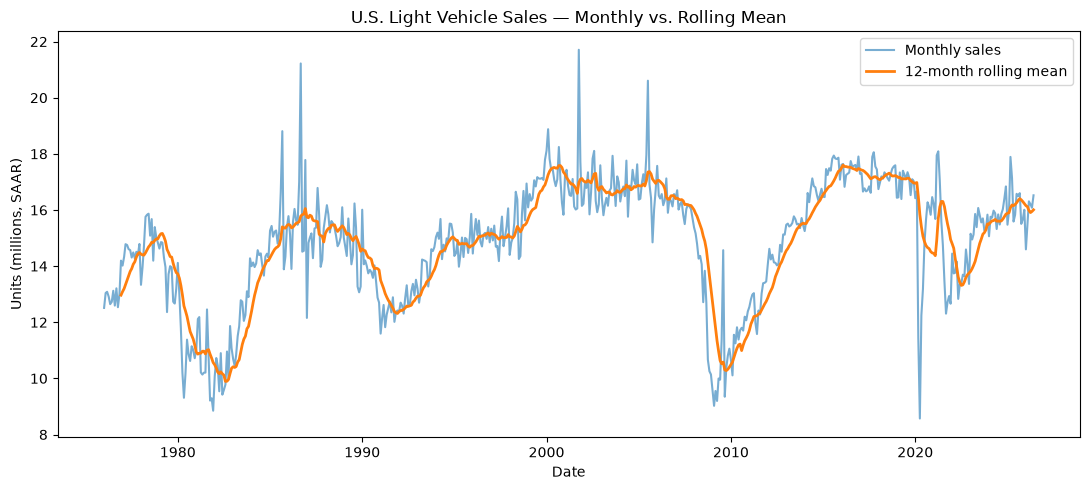

In [7]:
rolling_mean = monthly.rolling(window=12).mean()

fig, ax = plt.subplots()
ax.plot(monthly.index, monthly, label="Monthly sales", alpha=0.6)
ax.plot(
    rolling_mean.index,
    rolling_mean,
    label="12-month rolling mean",
    linewidth=2,
)
ax.set_title("U.S. Light Vehicle Sales — Monthly vs. Rolling Mean")
ax.set_xlabel("Date")
ax.set_ylabel("Units (millions, SAAR)")
ax.legend()
fig.tight_layout()
fig.savefig("outputs/monthly_vs_rolling_mean.png", dpi=150)
plt.show()

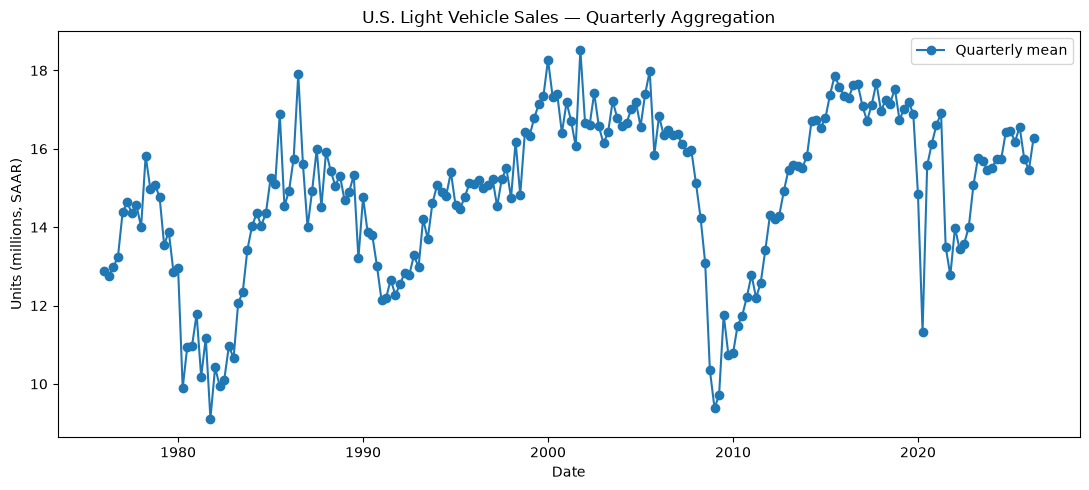

In [8]:
fig, ax = plt.subplots()
ax.plot(
    quarterly.index, quarterly, marker="o", label="Quarterly mean"
)
ax.set_title("U.S. Light Vehicle Sales — Quarterly Aggregation")
ax.set_xlabel("Date")
ax.set_ylabel("Units (millions, SAAR)")
ax.legend()
fig.tight_layout()
fig.savefig("outputs/quarterly_sales.png", dpi=150)
plt.show()

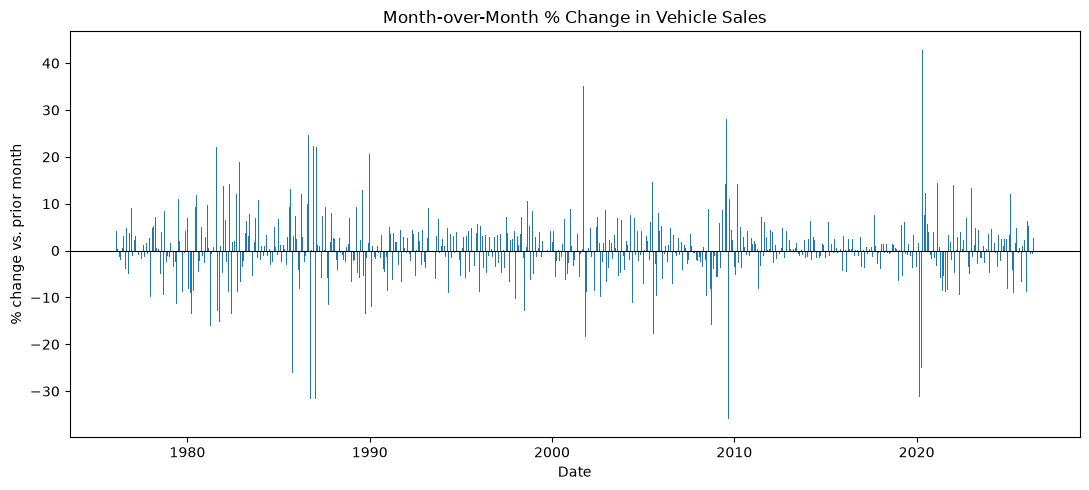

In [9]:
fig, ax = plt.subplots()
ax.bar(monthly_df.index, monthly_df["mom_pct_change"], width=20)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Month-over-Month % Change in Vehicle Sales")
ax.set_xlabel("Date")
ax.set_ylabel("% change vs. prior month")
fig.tight_layout()
fig.savefig("outputs/mom_pct_change.png", dpi=150)
plt.show()

## Findings

- The series is a clean monthly `DatetimeIndex` with no gaps
  against `pd.date_range(freq="MS")`, so no reindexing/filling
  was needed before resampling.
- Quarterly resampling smooths the sharp month-to-month swings
  visible in the raw series, making longer cycles easier to read.
- Month-over-month `%` change is highly volatile and noisy —
  useful for spotting shocks (e.g. 2020 COVID collapse) but not
  for reading the underlying trend on its own.
- The 12-month rolling mean is the clearest way to see the
  trend: it removes seasonal noise and confirms why analysts
  differencing/rolling before comparing periods in sales data.